### Loading the dataset

In [1]:
from torch_geometric.datasets import TUDataset

m_data = TUDataset(root = 'data/TUDataset', name = 'MUTAG')
print("Dataset:",m_data)
print("Number of graphs:",len(m_data))
print("Number of features:",m_data.num_features)
print("Number of classes:",m_data.num_classes)

Dataset: MUTAG(188)
Number of graphs: 188
Number of features: 7
Number of classes: 2


### Class Distribution

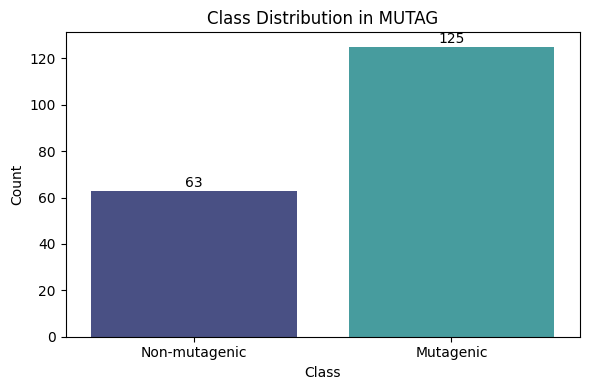

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

y = m_data.data.y.numpy()
unique, counts = np.unique(y, return_counts=True)
class_names = ['Non-mutagenic', 'Mutagenic']

plt.figure(figsize=(6,4))
ax = sns.barplot(x=class_names, y=counts, palette='mako')

for i, v in enumerate(counts):
    ax.text(i, v + 0.2, str(v), ha='center', va='bottom')

plt.title("Class Distribution in MUTAG")
plt.ylabel("Count")
plt.xlabel("Class")
plt.tight_layout()
plt.show()

### Node and edge counts

In [5]:
nodes = [data.num_nodes for data in m_data]
edges = [data.edge_index.size(1) for data in m_data]

print(f"Average number of nodes: {np.mean(nodes):.2f}")
print(f"Average number of edges: {np.mean(edges):.2f}")
print(f"Median number of nodes: {np.median(nodes):.2f}")
print(f"Median number of edges: {np.median(edges):.2f}")

Average number of nodes: 17.93
Average number of edges: 39.59
Median number of nodes: 17.50
Median number of edges: 38.00


### Average node and edge distribution

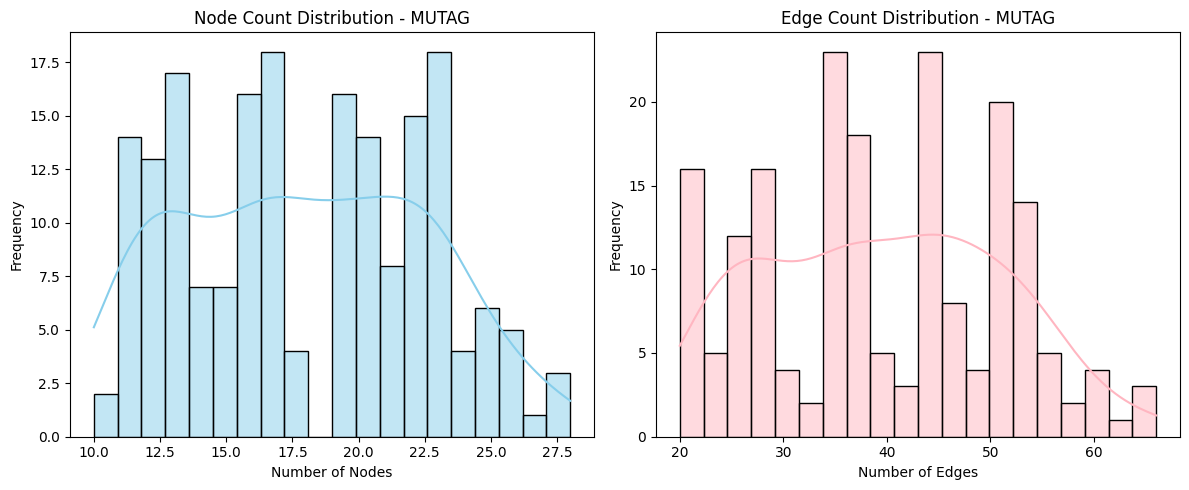

In [7]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.histplot(nodes, bins=20, kde=True, color='skyblue')
plt.title("Node Count Distribution - MUTAG")
plt.xlabel("Number of Nodes")
plt.ylabel("Frequency")

plt.subplot(1,2,2)
sns.histplot(edges, bins=20, kde=True, color='lightpink')
plt.title("Edge Count Distribution - MUTAG")
plt.xlabel("Number of Edges")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

### Average degree distribution

Average Degree (overall): 4.38


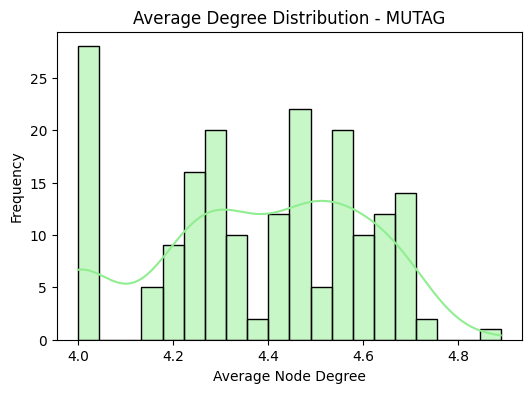

In [9]:
avg_deg = [2 * e / n for e, n in zip(edges, nodes)]
print(f"Average Degree (overall): {np.mean(avg_deg):.2f}")

plt.figure(figsize=(6,4))
sns.histplot(avg_deg, bins=20, kde=True, color='lightgreen')
plt.title("Average Degree Distribution - MUTAG")
plt.xlabel("Average Node Degree")
plt.ylabel("Frequency")
plt.show()

### Atom type distribution

In [11]:
import torch

atom_mapping = {
        0: "C",  
        1: "O",  
        2: "Cl", 
        3: "H",  
        4: "N",  
        5: "F",  
        6: "Br"
    }

node_labels_all = []

for data in m_data:
    if data.x is not None:
        atom_indices = torch.argmax(data.x, dim=1).numpy()
        node_labels_all.extend(atom_indices)

atom_names = [atom_mapping[i] for i in node_labels_all if i in atom_mapping]

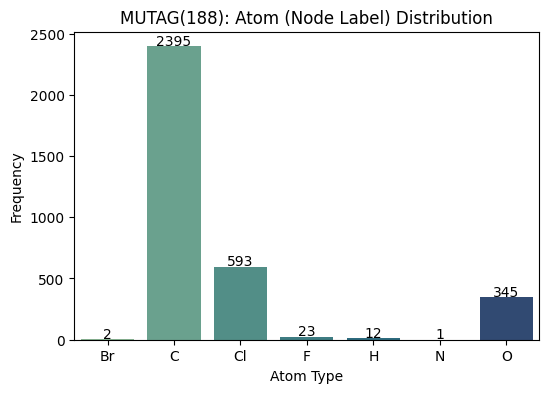

In [13]:
unique_atoms, counts = np.unique(atom_names, return_counts=True)

plt.figure(figsize=(6,4))
sns.barplot(x=unique_atoms, y=counts, palette="crest")
for i, v in enumerate(counts):
    plt.text(i, v + 10, str(v), ha='center')
plt.title(f"{m_data}: Atom (Node Label) Distribution")
plt.xlabel("Atom Type")
plt.ylabel("Frequency")
plt.show()

### Bond type distribution

In [15]:
bond_mapping = {
    0: 'aromatic',
    1: 'single',
    2: 'double',
    3: 'triple'
}

In [17]:
from collections import Counter

bond_counts = Counter()

for data in m_data:
    if data.edge_attr is not None:
        edge_types = torch.argmax(data.edge_attr, dim=1).numpy()
        bond_counts.update(edge_types)

bond_labels = [bond_mapping.get(k, f"Type {k}") for k in bond_counts.keys()]
counts = list(bond_counts.values())

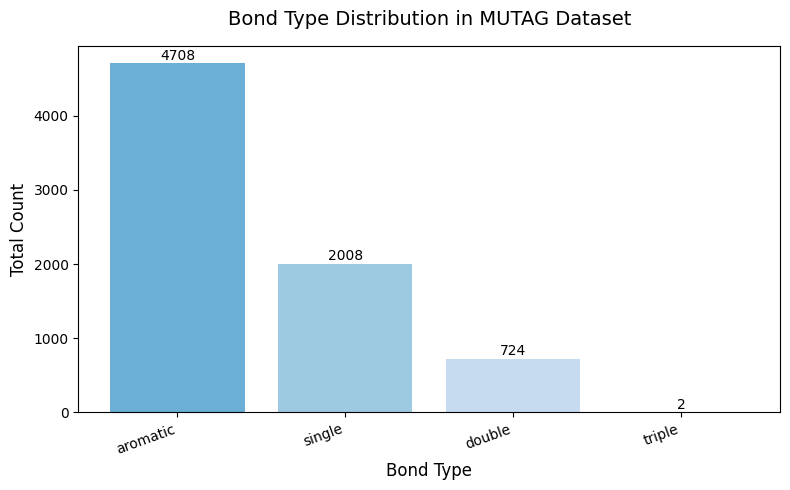

In [19]:
plt.figure(figsize=(8, 5))
bars = plt.bar(bond_labels, counts, color=['#6BAED6', '#9ECAE1', '#C6DBEF', '#DEEBF7'])

plt.title("Bond Type Distribution in MUTAG Dataset", fontsize=14, pad=15)
plt.xlabel("Bond Type", fontsize=12)
plt.ylabel("Total Count", fontsize=12)
plt.xticks(rotation=20, ha='right')

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 5, int(yval), ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

### Visualizing a compound from the data

In [21]:
from torch_geometric.utils import to_networkx

data = m_data[21]
G = to_networkx(data)

edge_types = torch.argmax(data.edge_attr, dim=1).numpy()
for i, (u, v) in enumerate(data.edge_index.T.numpy()):
    G[u][v]['bond_type'] = int(edge_types[i])

atom_indices = torch.argmax(data.x, dim=1).numpy()
node_labels = {i: atom_mapping.get(int(atom_indices[i]), str(int(atom_indices[i]))) 
               for i in range(len(atom_indices))}

bond_style = {
    0: {'color': 'purple', 'style': 'dotted', 'label': 'Aromatic (0)'},
    1: {'color': 'gray', 'style': 'solid',  'label': 'Single (1)'},
    2: {'color': 'orange', 'style': 'dashed', 'label': 'Double (2)'},
    3: {'color': 'red', 'style': (0, (3, 1, 1, 1)), 'label': 'Triple (3)'} }

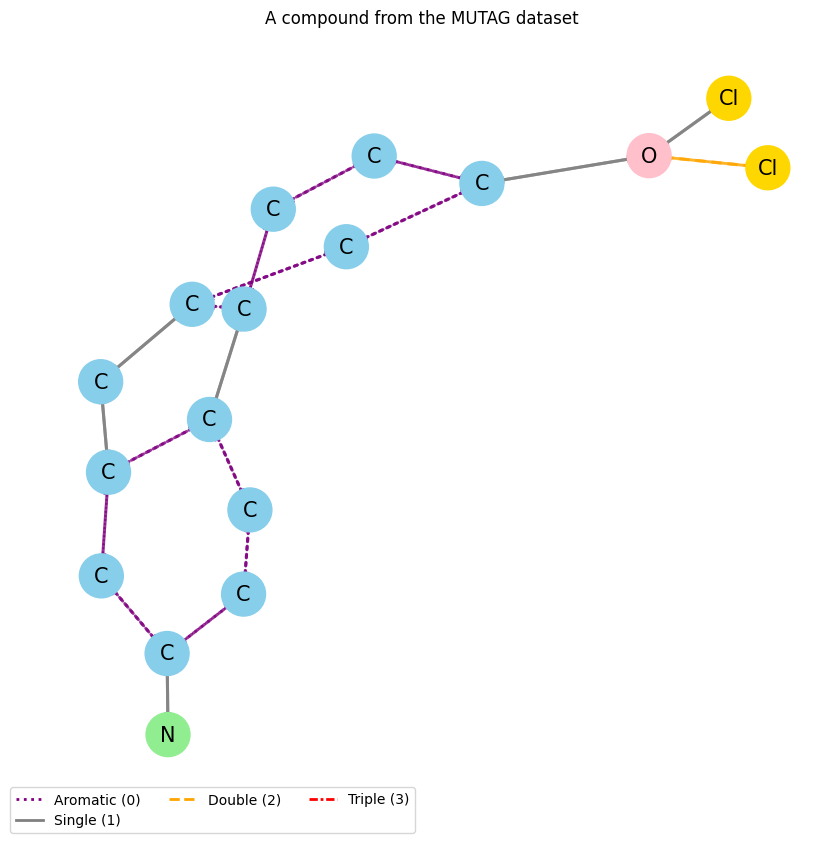

In [23]:
import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

pos = nx.spring_layout(G, k=0.1, seed=42)
fig, ax = plt.subplots(figsize=(10, 10))

atom_colors = {
    'C': 'skyblue',
    'O': 'pink',
    'N': 'lightgreen',
    'H': 'lavender',
    'F': 'lightgray',
    'Cl': 'gold',
    'Br': 'seashell'
}

node_color_list = [
    atom_colors.get(node_labels[n], 'lightgray') 
    for n in G.nodes()
]

nx.draw_networkx_nodes(
    G, pos,
    node_color=node_color_list,
    node_size=1000,
    ax=ax
)

nx.draw_networkx_labels(
    G, pos,
    labels=node_labels,
    font_size=15,
    font_color='black',
    ax=ax
)

for bond_type, style in bond_style.items():
    edges = [(u, v) for u, v, d in G.edges(data=True) if d.get('bond_type') == bond_type]
    if edges:
        nx.draw_networkx_edges(
            G, pos,
            edgelist=edges,
            edge_color=style['color'],
            style=style['style'],
            width=2.2,
            ax=ax,
            alpha=0.8
        )

legend_elements = [
    Line2D([0], [0], color=s['color'], lw=2, linestyle=s['style'], label=s['label'])
    for s in bond_style.values()
]
ax.legend(handles=legend_elements, loc='lower right',
          bbox_to_anchor=(0.5, -0.05), ncol=3, fontsize=10)
plt.axis('off')
plt.title('A compound from the MUTAG dataset')
plt.show()

### Extracting graphs and labels

In [25]:
import numpy as np

graphs, labels = [], []
for data in m_data:
    edges = data.edge_index.numpy().T  
    edge_list = [tuple(e) for e in edges]
    
    if data.x is not None:
        node_labels = {i: int(np.argmax(feat)) for i, feat in enumerate(data.x.numpy())}
    else:
        node_labels = {i: 0 for i in range(data.num_nodes)}

    graphs.append((edge_list, node_labels))
    labels.append(int(data.y))

### Function for evaluation metrics

In [27]:
from sklearn.metrics import f1_score, confusion_matrix, precision_score, accuracy_score, recall_score

In [29]:
def evaluate_model(cl, K_tst, yt, model_name="Model", yp_override=None):
    if yp_override is not None:
        yp = yp_override
    else:
        yp = cl.predict(K_tst)  
    
    ac = accuracy_score(yt, yp)
    pr = precision_score(yt, yp, zero_division=0)
    rc = recall_score(yt, yp, zero_division=0)
    f1 = f1_score(yt, yp, zero_division=0)
    cm = confusion_matrix(yt, yp)
    
    print(model_name, "Evaluation")
    print("Accuracy:", round(ac,4))
    print("Precision:", round(pr,4))
    print("Recall:", round(rc,4))
    print("F1-score:", round(f1,4))
    print("Confusion Matrix:\n", cm)
    
    return {
        "Model": model_name,
        "Accuracy": ac,
        "Precision": pr,
        "Recall": rc,
        "F1_Score": f1,
    }

In [31]:
results = []

## Graph Kernels

### 1. Weisfeiler Lehman Kernel

In [33]:
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split, cross_val_predict
from grakel.kernels import WeisfeilerLehman, VertexHistogram
from sklearn.svm import SVC
import warnings
warnings.filterwarnings("ignore")

In [35]:
X_trn, X_tst, y_trn, y_tst = train_test_split(graphs, labels, test_size = 0.2, random_state = 42, stratify = labels)

def format_for_grakel(graph_tuple):
    edges, labels = graph_tuple
    return (edges, labels)

X_trn = [format_for_grakel(g) for g in X_trn]
X_tst = [format_for_grakel(g) for g in X_tst]

gk = WeisfeilerLehman(n_iter = 5, base_graph_kernel = VertexHistogram)

K_trn = gk.fit_transform(X_trn)       
K_tst = gk.transform(X_tst)             

cl = SVC(kernel="precomputed")
cl.fit(K_trn, y_trn)

,C,1.0
,kernel,'precomputed'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [37]:
res_wl = evaluate_model(cl, K_tst, y_tst, model_name="Weisfeiler-Lehman Kernel")
results.append(res_wl)

Weisfeiler-Lehman Kernel Evaluation
Accuracy: 0.7632
Precision: 0.8333
Recall: 0.8
F1-score: 0.8163
Confusion Matrix:
 [[ 9  4]
 [ 5 20]]


In [39]:
y = m_data.data.y.numpy()
kf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
cl = SVC(kernel="precomputed")

wl = WeisfeilerLehman(n_iter = 3, base_graph_kernel = VertexHistogram)
Kwl = wl.fit_transform(graphs)

sc_wl = cross_val_score(cl, Kwl, y, cv=kf, scoring="accuracy")

print("Weisfeiler-Lehman Kernel Results:")
print("10-Fold Cross-Validation Accuracies:", sc_wl)
print("Mean Accuracy:", np.mean(sc_wl))
print("Std Dev:", np.std(sc_wl))

Weisfeiler-Lehman Kernel Results:
10-Fold Cross-Validation Accuracies: [0.84210526 0.78947368 0.89473684 0.94736842 0.68421053 0.73684211
 0.73684211 0.89473684 0.88888889 0.77777778]
Mean Accuracy: 0.8192982456140351
Std Dev: 0.08222355318230991


### 2. Shortest Path Kernel

In [41]:
from grakel.kernels import ShortestPath

In [43]:
X_trn, X_tst, y_trn, y_tst = train_test_split(graphs, labels, test_size = 0.2, random_state = 42, stratify = labels)

def format_for_grakel(graph_tuple):
    edges, labels = graph_tuple
    return (edges, labels)

X_trn = [format_for_grakel(g) for g in X_trn]
X_tst = [format_for_grakel(g) for g in X_tst]
y = np.array(labels)


sp = ShortestPath(with_labels=True)
Ksp = sp.fit_transform(graphs)

for tr_index, tst_index in kf.split(np.zeros(len(y)), y):
    K_trn, K_tst = Ksp[tr_index][:, tr_index], Ksp[tst_index][:, tr_index]
    y_trn, y_tst = y[tr_index], y[tst_index]

    cl = SVC(kernel="precomputed")
    cl.fit(K_trn, y_trn)

results_sp = evaluate_model(cl, K_tst, y_tst, model_name="Shortest Path Kernel")
results.append(results_sp)

Shortest Path Kernel Evaluation
Accuracy: 0.8333
Precision: 0.9091
Recall: 0.8333
F1-score: 0.8696
Confusion Matrix:
 [[ 5  1]
 [ 2 10]]


In [45]:
sp = ShortestPath(normalize=True)
Ksp = sp.fit_transform(graphs)

sc_sp = cross_val_score(cl, Ksp, y, cv=kf, scoring="accuracy")

print("Shortest-Path Kernel Results:")
print("10-Fold Cross-Validation Accuracies:", sc_sp)
print("Mean Accuracy:", np.mean(sc_sp))
print("Std Dev:", np.std(sc_sp))

Shortest-Path Kernel Results:
10-Fold Cross-Validation Accuracies: [0.89473684 0.68421053 0.94736842 0.78947368 0.63157895 0.78947368
 0.84210526 0.78947368 0.83333333 0.88888889]
Mean Accuracy: 0.80906432748538
Std Dev: 0.09097327215754292


## Graph Embeddings

### Preparing data for embedding algorithms

In [47]:
from torch_geometric.utils import to_networkx

In [49]:
graphs_nx = []
labels = []

for data in m_data:
    G = to_networkx(data, to_undirected=True)
    graphs_nx.append(G)
    labels.append(int(data.y))

### 1. Node2Vec

In [51]:
import torch as t
from torch_geometric.nn.models import Node2Vec

In [53]:
def get_node2vec_embeddings(graphs, dimensions=64, w_length=10, c_size=5, w_per_node=10, p=1, q=1, epochs=20):
    embeddings = []
    device = 'cuda' if t.cuda.is_available() else 'cpu'
    
    for G in graphs:
        eg_index = t.tensor(list(G.edges), dtype = t.long).t().contiguous()
        if eg_index.numel() == 0:
            embeddings.append(np.zeros(dimensions))
            continue
        
        n2v = Node2Vec(eg_index, embedding_dim = dimensions, walk_length = w_length,
                         context_size = c_size, walks_per_node = w_per_node,
                         p=p, q=q, sparse=True).to(device)
        
        l = n2v.loader(batch_size=128, shuffle=True)
        opt = t.optim.SparseAdam(list(n2v.parameters()), lr=0.01)

        n2v.train()
        for epoch in range(epochs):
            total_loss = 0
            for pos_rw, neg_rw in l:
                opt.zero_grad()
                loss = n2v.loss(pos_rw.to(device), neg_rw.to(device))
                loss.backward()
                opt.step()
                total_loss += loss.item()
        
        n2v.eval()
        node_emb = n2v.embedding.weight.detach().cpu().numpy()
        graph_emb = np.mean(node_emb, axis=0)
        embeddings.append(graph_emb)
    
    return np.array(embeddings)

In [55]:
X_trn_idx, X_tst_idx = train_test_split(np.arange(len(m_data)), test_size = 0.2, stratify = labels, random_state = 42)
y_trn = np.array(labels)[X_trn_idx]
y_tst = np.array(labels)[X_tst_idx]

In [57]:
x_n2v = get_node2vec_embeddings(graphs_nx, p=0.5, q=2.0)
y = np.array(labels)
X_trn = x_n2v[X_trn_idx]
X_tst = x_n2v[X_tst_idx]

cl = SVC(kernel='rbf', C = 1, gamma = 'scale', random_state = 42)
cl.fit(X_trn, y_trn)

results_node2vec = evaluate_model(cl, X_tst, y_tst, model_name="Node2Vec")
results.append(results_node2vec)

Node2Vec Evaluation
Accuracy: 0.7632
Precision: 0.7667
Recall: 0.92
F1-score: 0.8364
Confusion Matrix:
 [[ 6  7]
 [ 2 23]]


In [59]:
kf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
sc_n2v = cross_val_score(cl, x_n2v, y, cv = kf, scoring = "accuracy")
print("10-Fold Cross-Validation Accuracies:", sc_n2v)
print("Mean Accuracy:", np.mean(sc_n2v))
print("Std Dev:", np.std(sc_n2v))

10-Fold Cross-Validation Accuracies: [0.78947368 0.68421053 0.84210526 0.68421053 0.68421053 0.73684211
 0.63157895 0.78947368 0.88888889 0.88888889]
Mean Accuracy: 0.7619883040935672
Std Dev: 0.08713450292397659


### 2. Edge2Vec

In [61]:
from gensim.models import Word2Vec
import random

In [63]:
def edge2vec_walk(G, start_edge, walk_length=10):
    walk = [start_edge]
    for _ in range(walk_length - 1):
        u, v, bond = walk[-1]
        nbrs = list(G.neighbors(v))
        if not nbrs:
            break
        nxt_n = random.choice(nbrs)
        nxt_b = G[v][nxt_n]['bond_type']
        walk.append((v, nxt_n, nxt_b))
    return [f"{u}-{v}-{bond}" for (u, v, bond) in walk]

In [65]:
all_w = []
graph_edges = []
labels = []

for data in m_data:
    G = to_networkx(data)
    edge_types = t.argmax(data.edge_attr, dim=1).numpy()
    edge_list = []

    for i, (u, v) in enumerate(data.edge_index.T.numpy()):
        G[u][v]['bond_type'] = int(edge_types[i])
        edge_list.append((u, v, int(edge_types[i])))

    graph_edges.append(edge_list)
    labels.append(int(data.y))

    for edge in edge_list:
        for _ in range(3):  
            all_w.append(edge2vec_walk(G, edge))

In [67]:
e2v = Word2Vec(sentences = all_w, vector_size = 64, window = 5, min_count = 1, sg = 1, workers = 4, seed = 42)

In [69]:
ge = []

for edge_list in graph_edges:
    emb_list = []
    for (u, v, bond_type) in edge_list:
        key = f"{u}-{v}-{bond_type}"
        if key in e2v.wv:
            emb_list.append(e2v.wv[key])
    if emb_list:
        ge.append(np.mean(emb_list, axis=0))
    else:
        ge.append(np.zeros(e2v.vector_size))

X_ = np.array(ge)
y_ = np.array(labels)

In [71]:
X_trn, X_tst, y_trn, y_tst = train_test_split(X_, y_, test_size = 0.2, stratify = y_, random_state = 42)

cl = SVC(kernel='rbf', C = 1, gamma = 'scale', probability = True, random_state = 42)
cl.fit(X_trn, y_trn)

results_edge2vec = evaluate_model(cl, X_tst, y_tst, model_name="Edge2Vec")
results.append(results_edge2vec)

Edge2Vec Evaluation
Accuracy: 0.8421
Precision: 0.88
Recall: 0.88
F1-score: 0.88
Confusion Matrix:
 [[10  3]
 [ 3 22]]


In [73]:
kf = StratifiedKFold(n_splits = 10, shuffle = True, random_state = 42)
accuracies = []

for trn_idx, tst_idx in kf.split(X_, y_):
    X_tr, X_te = X_[trn_idx], X_[tst_idx]
    y_tr, y_te = y_[trn_idx], y_[tst_idx]
    cl_cv = SVC(kernel='rbf', random_state=42)
    cl_cv.fit(X_tr, y_tr)
    yp_cv = cl_cv.predict(X_te)
    accuracies.append(accuracy_score(y_te, yp_cv))

accuracies = np.array(accuracies)
print("10-Fold Cross-Validation Accuracies:", accuracies)
print(f"Mean Accuracy: {accuracies.mean():.4f}")
print(f"Std Dev: {accuracies.std():.4f}")

10-Fold Cross-Validation Accuracies: [0.89473684 0.68421053 0.89473684 0.84210526 0.73684211 0.73684211
 0.84210526 0.78947368 0.88888889 0.88888889]
Mean Accuracy: 0.8199
Std Dev: 0.0741


### 3. DeepWalk

In [75]:
x_dw = get_node2vec_embeddings(graphs_nx, p=1, q=1)
y = np.array(labels)
X_trn = x_dw[X_trn_idx]
X_tst = x_dw[X_tst_idx]

cl = SVC(kernel = 'rbf', C = 1, gamma = 'scale', random_state = 42)
cl.fit(X_trn, y_trn)

results_deepwalk = evaluate_model(cl, X_tst, y_tst, model_name="DeepWalk")
results.append(results_deepwalk)

DeepWalk Evaluation
Accuracy: 0.7632
Precision: 0.75
Recall: 0.96
F1-score: 0.8421
Confusion Matrix:
 [[ 5  8]
 [ 1 24]]


In [76]:
kf = StratifiedKFold(n_splits = 10, shuffle = True, random_state = 42)
sc_deepwalk = cross_val_score(cl, x_dw, y, cv = kf, scoring="accuracy")
print("10-Fold Cross-Validation Accuracies:", sc_deepwalk)
print("Mean Accuracy:", np.mean(sc_deepwalk))
print("Std Dev:", np.std(sc_deepwalk))

10-Fold Cross-Validation Accuracies: [0.68421053 0.78947368 0.94736842 0.78947368 0.73684211 0.73684211
 0.78947368 0.84210526 0.72222222 0.83333333]
Mean Accuracy: 0.7871345029239766
Std Dev: 0.07121308862120489


## Neural-Network-based apporach

In [79]:
import torch.nn.functional as F
from torch_geometric.nn import GCNConv, global_mean_pool
from torch_geometric.loader import DataLoader

In [81]:
device = t.device('cuda' if t.cuda.is_available() else 'cpu')

### 1. GCN (Graph Convolutional Network)

In [83]:
class GCN(t.nn.Module):
    def __init__(self, in_, hidden, out):
        super(GCN, self).__init__()
        self.c1 = GCNConv(in_, hidden)
        self.c2 = GCNConv(hidden, hidden)
        self.l = t.nn.Linear(hidden, out)

    def forward(self, x, eg_index, batch):
        x = self.c1(x, eg_index)
        x = F.relu(x)
        x = self.c2(x, eg_index)
        x = F.relu(x)
        x = global_mean_pool(x, batch)
        x = self.l(x)
        return x

In [85]:
labels = np.array([int(data.y.item()) for data in m_data])
k_f = StratifiedKFold(n_splits = 10, shuffle = True, random_state = 42)
all_y_true, all_y_pred = [], []

for trn_idx, tst_idx in k_f.split(np.zeros(len(labels)), labels):
    trn_data = m_data[t.tensor(trn_idx)]
    tst_data = m_data[t.tensor(tst_idx)]

    trn_loader = DataLoader(trn_data, batch_size = 32, shuffle = True)
    tst_loader = DataLoader(tst_data, batch_size = 32, shuffle = False)

    gcn = GCN(m_data.num_features, 64, m_data.num_classes).to(device)  
    opt = t.optim.Adam(gcn.parameters(), lr=0.01)

    gcn.train()
    for epoch in range(50):
        for d in trn_loader:
            d = d.to(device)
            opt.zero_grad()
            o = gcn(d.x, d.edge_index, d.batch)
            loss = F.cross_entropy(o, d.y)
            loss.backward()
            opt.step()

    ytr, yp = [], []

    gcn.eval()
    for d in tst_loader:
        d = d.to(device)
        o = gcn(d.x, d.edge_index, d.batch)
        pred = o.argmax(dim=1).cpu().numpy()
        yp.extend(pred)
        ytr.extend(d.y.cpu().numpy())
    
results_gcn = evaluate_model(None, None, np.array(ytr), model_name="GCN", yp_override=np.array(yp))
results.append(results_gcn)

GCN Evaluation
Accuracy: 0.7778
Precision: 0.8333
Recall: 0.8333
F1-score: 0.8333
Confusion Matrix:
 [[ 4  2]
 [ 2 10]]


## 2. GraphSAGE

In [87]:
from torch_geometric.nn import SAGEConv

In [89]:
class GraphSAGE(t.nn.Module):
    def __init__(self, in_, hidden, out):
        super(GraphSAGE, self).__init__()
        self.c1 = SAGEConv(in_, hidden)
        self.c2 = SAGEConv(hidden, hidden)
        self.l = t.nn.Linear(hidden, out)

    def forward(self, x, eg_index, b):
        x = self.c1(x, eg_index)
        x = F.relu(x)
        x = self.c2(x, eg_index)
        x = F.relu(x)
        x = global_mean_pool(x, b)
        x = self.l(x)
        return x

In [91]:
labels = np.array([int(d.y.item()) for d in m_data])
kf = StratifiedKFold(n_splits = 10, shuffle = True, random_state = 42)
yts, yps = [], []
for trn_idx, tst_idx in kf.split(np.zeros(len(labels)), labels):
    trn_dataset = [m_data[i] for i in trn_idx]
    tst_dataset = [m_data[i] for i in tst_idx]

    trn_loader = DataLoader(trn_dataset, batch_size = 32, shuffle = True)
    tst_loader = DataLoader(tst_dataset, batch_size = 32, shuffle = False)

    gS = GraphSAGE(m_data.num_features, 64, m_data.num_classes).to(device)
    opt = t.optim.Adam(gS.parameters(), lr = 0.01)

    gS.train()
    for epoch in range(50):
        tl = 0
        for d in trn_loader:
            d = d.to(device)
            opt.zero_grad()
            o = gS(d.x, d.edge_index, d.batch)
            loss = F.cross_entropy(o, d.y)
            loss.backward()
            opt.step()
            tl += loss.item()


    gS.eval()
    for d in tst_loader:
        d = d.to(device)
        o = gS(d.x, d.edge_index, d.batch)
        p = o.argmax(dim=1).cpu().numpy()
        yps.extend(p)
        yts.extend(d.y.cpu().numpy())
    
results_GS = evaluate_model(None, None, np.array(yts), model_name="GraphSage", yp_override=np.array(yps))
results.append(results_GS)

GraphSage Evaluation
Accuracy: 0.7713
Precision: 0.7929
Recall: 0.888
F1-score: 0.8377
Confusion Matrix:
 [[ 34  29]
 [ 14 111]]


### Results

In [96]:
import pandas as pd

results_df = pd.DataFrame(results)
results_df

,Model,Accuracy,Precision,Recall,F1_Score
0,Weisfeiler-Lehman Kernel,0.763158,0.833333,0.800000,0.816327
1,Shortest Path Kernel,0.833333,0.909091,0.833333,0.869565
2,Node2Vec,0.763158,0.766667,0.920000,0.836364
3,Edge2Vec,0.842105,0.880000,0.880000,0.880000
4,DeepWalk,0.763158,0.750000,0.960000,0.842105
5,GCN,0.777778,0.833333,0.833333,0.833333
6,GraphSage,0.771277,0.792857,0.888000,0.837736


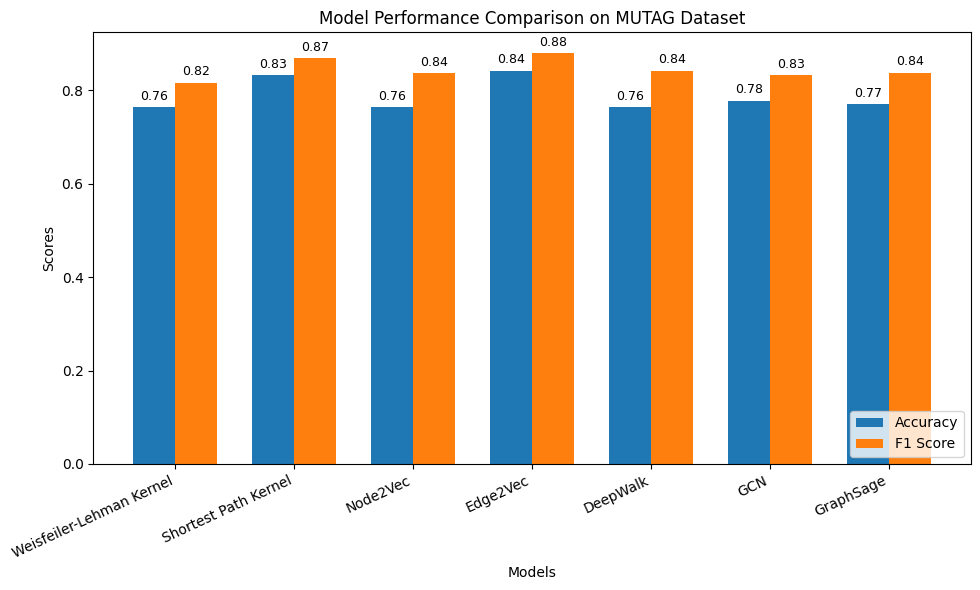

In [98]:
data = {
    'Model': results_df['Model'],
    'Accuracy': results_df['Accuracy'],
    'F1_score': results_df['F1_Score']
}

df = pd.DataFrame(data)

x = np.arange(len(df['Model']))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
rects1 = ax.bar(x - width/2, df['Accuracy'], width, label='Accuracy')
rects2 = ax.bar(x + width/2, df['F1_score'], width, label='F1 Score')

ax.set_ylabel('Scores')
ax.set_xlabel('Models')
ax.set_title('Model Performance Comparison on MUTAG Dataset')
ax.set_xticks(x)
ax.set_xticklabels(df['Model'], rotation=25, ha='right')
ax.legend(loc='lower right')

for rect in rects1 + rects2:
    height = rect.get_height()
    ax.annotate(f'{height:.2f}',
                xy=(rect.get_x() + rect.get_width()/2, height),
                xytext=(0, 3),  
                textcoords="offset points",
                ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()